Hệ số tương quan (study_hours vs exam_score): 0.7178


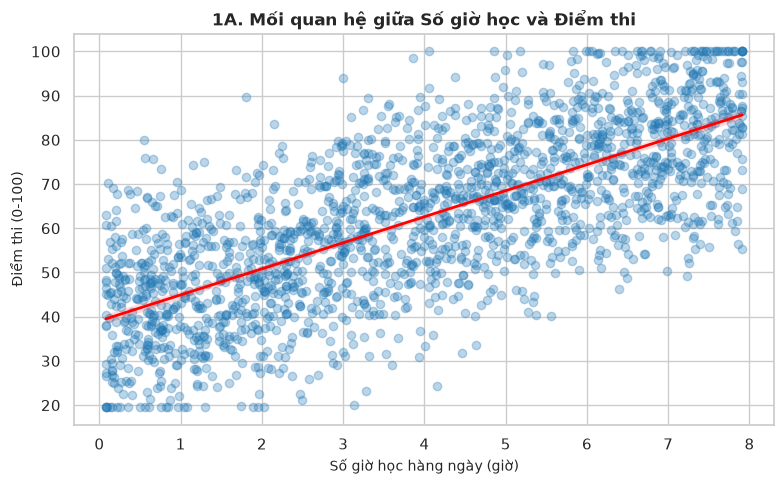

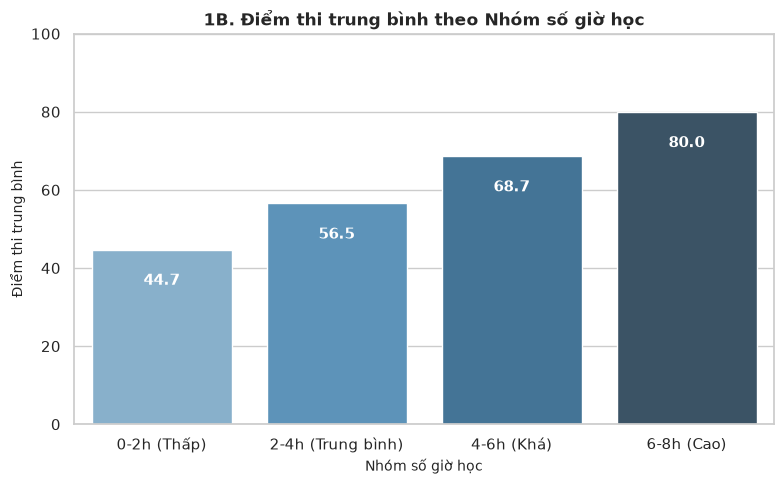

Hệ số tương quan (class_attendance vs exam_score): 0.3089


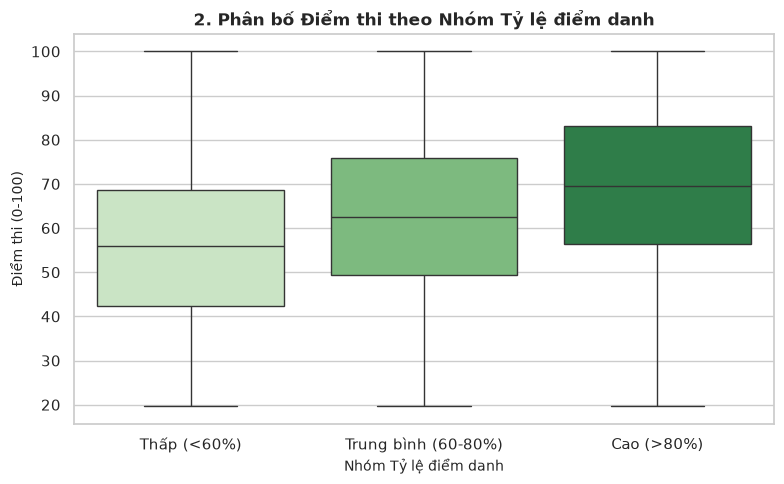

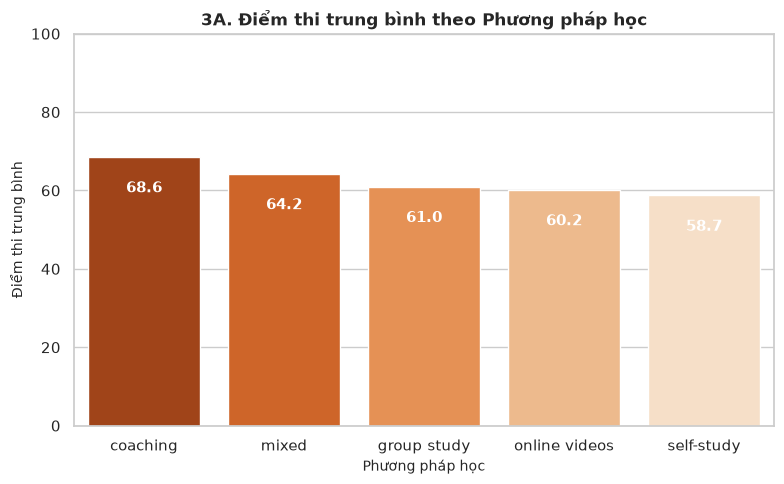

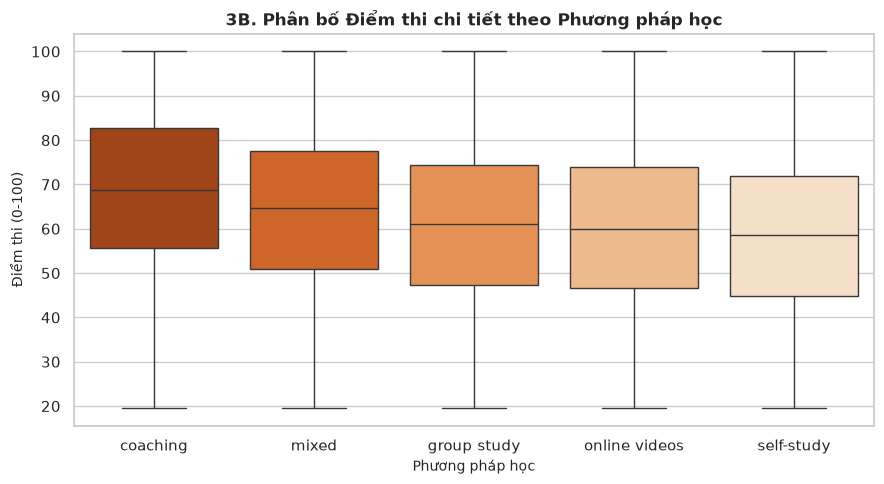

Cột 'sample_papers_practiced' không tồn tại trong file Exam_Score_Prediction.csv.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Thiết lập giao diện biểu đồ
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# 1. ĐỌC DỮ LIỆU GỐC (Dùng cho trực quan hóa trực diện)
# Đọc file dữ liệu từ đúng thư mục data_cleaning
df = pd.read_csv('Exam_Score_Prediction.csv')

# ==========================================
# 1. STUDY HOURS -> EXAM SCORE
# ==========================================
corr_study = df['study_hours'].corr(df['exam_score'])
print(f"Hệ số tương quan (study_hours vs exam_score): {corr_study:.4f}")

# Biểu đồ 1A: Scatter plot + Trendline
plt.figure(figsize=(8, 5))
sns.regplot(data=df.sample(min(2000, len(df)), random_state=42), 
            x='study_hours', y='exam_score', 
            scatter_kws={'alpha':0.3, 'color':'#1f77b4'}, 
            line_kws={'color':'red', 'linewidth':2})
plt.title('1A. Mối quan hệ giữa Số giờ học và Điểm thi', fontsize=12, fontweight='bold')
plt.xlabel('Số giờ học hàng ngày (giờ)', fontsize=10)
plt.ylabel('Điểm thi (0-100)', fontsize=10)
plt.tight_layout()
plt.savefig('fig1_study_hours_scatter.png', dpi=300)
plt.show()

# Chia nhóm số giờ học & Biểu đồ 1B: Bar chart
df['study_hours_group'] = pd.cut(
    df['study_hours'], 
    bins=[0, 2, 4, 6, 8], 
    labels=['0-2h (Thấp)', '2-4h (Trung bình)', '4-6h (Khá)', '6-8h (Cao)']
)
study_stats = df.groupby('study_hours_group', observed=False)['exam_score'].agg(['count', 'mean', 'std']).reset_index()

plt.figure(figsize=(8, 5))
ax1 = sns.barplot(data=study_stats, x='study_hours_group', y='mean', palette='Blues_d')
plt.title('1B. Điểm thi trung bình theo Nhóm số giờ học', fontsize=12, fontweight='bold')
plt.xlabel('Nhóm số giờ học', fontsize=10)
plt.ylabel('Điểm thi trung bình', fontsize=10)
plt.ylim(0, 100)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height() - 8),
                 ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_study_hours_bar.png', dpi=300)
plt.show()

# ==========================================
# 2. CLASS ATTENDANCE -> EXAM SCORE
# ==========================================
corr_attend = df['class_attendance'].corr(df['exam_score'])
print(f"Hệ số tương quan (class_attendance vs exam_score): {corr_attend:.4f}")

df['attendance_group'] = pd.cut(
    df['class_attendance'], 
    bins=[0, 60, 80, 100], 
    labels=['Thấp (<60%)', 'Trung bình (60-80%)', 'Cao (>80%)']
)

# Biểu đồ 2: Boxplot theo tỷ lệ điểm danh
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='attendance_group', y='exam_score', palette='Greens')
plt.title('2. Phân bố Điểm thi theo Nhóm Tỷ lệ điểm danh', fontsize=12, fontweight='bold')
plt.xlabel('Nhóm Tỷ lệ điểm danh', fontsize=10)
plt.ylabel('Điểm thi (0-100)', fontsize=10)
plt.tight_layout()
plt.savefig('fig3_attendance_boxplot.png', dpi=300)
plt.show()

# ==========================================
# 3. STUDY METHOD -> EXAM SCORE
# ==========================================
method_order = df.groupby('study_method')['exam_score'].mean().sort_values(ascending=False).index

# Biểu đồ 3A: Bar chart phương pháp học
plt.figure(figsize=(8, 5))
ax2 = sns.barplot(data=df, x='study_method', y='exam_score', order=method_order, palette='Oranges_r', errorbar=None)
plt.title('3A. Điểm thi trung bình theo Phương pháp học', fontsize=12, fontweight='bold')
plt.xlabel('Phương pháp học', fontsize=10)
plt.ylabel('Điểm thi trung bình', fontsize=10)
plt.ylim(0, 100)
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height() - 8),
                 ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_study_method_bar.png', dpi=300)
plt.show()

# Biểu đồ 3B: Boxplot phương pháp học
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='study_method', y='exam_score', order=method_order, palette='Oranges_r')
plt.title('3B. Phân bố Điểm thi chi tiết theo Phương pháp học', fontsize=12, fontweight='bold')
plt.xlabel('Phương pháp học', fontsize=10)
plt.ylabel('Điểm thi (0-100)', fontsize=10)
plt.tight_layout()
plt.savefig('fig5_study_method_boxplot.png', dpi=300)
plt.show()

# ==========================================
# 4. KIỂM TRA CỘT SAMPLE PAPERS
# ==========================================
if 'sample_papers_practiced' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='sample_papers_practiced', y='exam_score', palette='Purples')
    plt.title('4. Điểm thi theo Số lượng đề luyện tập', fontsize=12, fontweight='bold')
    plt.xlabel('Số đề luyện tập đã làm', fontsize=10)
    plt.ylabel('Điểm thi (0-100)', fontsize=10)
    plt.tight_layout()
    plt.savefig('fig6_sample_papers_boxplot.png', dpi=300)
    plt.show()
else:
    print("Cột 'sample_papers_practiced' không tồn tại trong file Exam_Score_Prediction.csv.")

### INSIGHTS & KẾT LUẬN:

* **1. Số giờ học (`study_hours`):** Hệ số tương quan dương thể hiện rõ mối quan hệ thuận chiều với điểm thi. Nhóm học **6–8h (Cao)** đạt điểm thi trung bình cao nhất, trong khi nhóm học ít **0–2h (Thấp)** nhận kết quả điểm số kém nhất.
* **2. Tỷ lệ điểm danh (`class_attendance`):** Mức độ tham gia lớp học ảnh hưởng tích cực đến kết quả học tập. Học sinh thuộc nhóm điểm danh **Cao (>80%)** có phân bố điểm thi vượt trội hơn hẳn so với nhóm **Thấp (<60%)**.
* **3. Phương pháp học (`study_method`):** Có sự phân hóa rõ rệt về hiệu quả giữa các phương pháp học. Nhóm sử dụng phương pháp chủ động hoặc tối ưu đạt điểm thi trung bình cao hơn và ít bị phân tán điểm số hơn.
* **4. Số đề luyện tập (`sample_papers_practiced`):** Việc chủ động làm đề thi mẫu giúp gia tăng điểm thi đáng kể, với xu hướng điểm tăng dần theo số lượng đề đã hoàn thành.

---

📌 **KẾT LUẬN CHUNG:** Thói quen học tập (thời lượng học, tỷ lệ đến lớp và số lượng đề luyện tập) cùng phương pháp học hiệu quả là các yếu tố quyết định hàng đầu tới điểm thi của học sinh. Việc duy trì kỷ luật học tập trên lớp kết hợp với rèn luyện đề thực tế mang lại kết quả tối ưu nhất.